# Hannover Re Strategic Assessment: The "Two-Gap" Climate Risk Thesis

### Executive Problem Statement
As an actuarial consultancy engaged by Hannover Re, our mandate is to evaluate how climate-related risks impact long-term financial resilience, specifically focusing on the Southeast Asian (SEA) property treaty reinsurance portfolio. 

Through exploratory data analysis, we hypothesize that the SEA reinsurance book is structurally mispriced due to two additive, compounding gaps:
1. **The Physical Risk Gap (Underpriced EAL):** Backward-looking empirical exposure models fail to capture the non-linear tail-risk expansion of extreme weather.
2. **The Transition Risk Gap (Unrecognized Compliance Costs):** Uniform regional pricing ignores drastic carbon-cost asymmetries between structurally different economies (e.g., Malaysia vs. the Philippines).

### The Causal Pathway: Linking GHG to Insurance Claims
To prove this thesis, this codebase integrates five heterogeneous datasets (WDI, NGFS GCAM, Climate Watch, CHIRPS, and EM-DAT). Rather than relying on naive direct correlation between GHG emissions and financial loss, we ground our methodology in the **IPCC AR6 Working Group I thermodynamic scaling principle**:
* **GHG Emissions** drive atmospheric warming.
* **Atmospheric Warming** dictates moisture-holding capacity via the Clausius-Clapeyron relation (**+7% extreme precipitation capacity per 1°C warming**).
* **Extreme Precipitation (RX5day)** non-linearly accelerates extreme flood and storm-related **Economic Damages (EM-DAT)**.

By establishing this mechanistic pathway, we can confidently project future loss distributions and regulatory costs without assuming linear historical correlations.

## Policy Alignment

This analysis aligns with the following frameworks and regulatory standards:

| Framework | Relevance |
|---|---|
| **BNM CCPT** (Bank Negara Malaysia Climate Change Principle-based Taxonomy, 2021) | Physical and transition risk classification for Malaysian financial institutions |
| **TCFD Recommendations** (2017, updated 2021) | Physical risk scenario analysis and transition risk stress testing methodology |
| **Paris Agreement Article 6** | Carbon market mechanisms underpinning NGFS carbon price trajectories |
| **IPCC AR6 WG1 Chapter 11** | ETCCDI RX5day as the standardised extreme precipitation index used in hazard analysis |
| **NGFS Phase IV Scenarios** (2023) | Net Zero 2050 carbon price pathway (USD 55.578/t) used in Exhibit 2 transition cost analysis |

> **Business context:** Hannover Re's SEA treaty book is exposed to two additive sources of reserve inadequacy:
> (1) physical risk — GEV-modelled EAL uplift from a 2007 precipitation regime shift, priced using CHIRPS RX5day and EM-DAT burning cost; and
> (2) transition risk — country-differentiated compliance cost from NGFS NZ2050 carbon pricing applied to Climate Watch GHG baselines.
> MYS and PHL require separate models: pooled SEA pricing is actuarially incorrect (different hazard types, LULUCF sign, and GDP materiality).


In [11]:
# ── Cell 1: Environment Setup & Data Loading ──────────────────────────────
# WHY: Initializes the analysis environment and loads all pre-processed
# datasets. This establishes the foundation for cross-referencing WDI macro
# indicators with Climate Watch sectoral GHG emissions and EM-DAT losses.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

DATA = Path("../data/processed")
OUT  = Path("../outputs")
OUT.mkdir(parents=True, exist_ok=True)

# ── LOAD ALL DATA FILES ───────────────────────────────────────────────────────
df_wdi    = pd.read_csv(DATA / "cleaned_wdi.csv")
df_chirps = pd.read_csv(DATA / "chirpsRX5_mls_phl.csv")
df_oni    = pd.read_csv(DATA / "noaa_oni_cleaned.csv")
df_emdat  = pd.read_csv(DATA / "EM_DAT_cleaned.csv")

REAL_SECTORS = [
    'Energy',
    'Industrial Processes',
    'Agriculture',
    'Waste',
    'Land Use, Land-Use Change and Forestry'
]
LULUCF = 'Land Use, Land-Use Change and Forestry'

def load_climatewatch(filepath):
    df = pd.read_csv(filepath)
    df = df[df['Sector'].isin(REAL_SECTORS)].copy()
    year_cols = [c for c in df.columns if str(c).isdigit()]
    df_long = df.melt(
        id_vars=['Sector', 'unit'],
        value_vars=year_cols,
        var_name='year',
        value_name='ghg_mtco2e'
    )
    df_long['year'] = df_long['year'].astype(int)
    df_long['ghg_mtco2e'] = pd.to_numeric(df_long['ghg_mtco2e'], errors='coerce')
    return df_long

df_cw_mys = load_climatewatch(DATA / "msia_climatewatch_lulucf.csv")
df_cw_phl = load_climatewatch(DATA / "phili_climatewatch_lulucf.csv")

# ── DATA INTEGRITY ASSERTIONS ─────────────────────────────────────────────────
assert 'RX5day_mm' in df_chirps.columns, \
    "CHIRPS column must be RX5day_mm — do NOT use '3-day max'"
assert 'WB_WDI_EN_GHG_ALL_MT_CE_AR5' in df_wdi.columns, \
    "WDI GHG column mismatch — check cleaned_wdi.csv"
assert 'WB_WDI_EN_GHG_CO2_PC_CE_AR5' in df_wdi.columns, \
    "WDI CO2 per capita column mismatch"
assert set(df_cw_mys['Sector'].unique()).issubset(set(REAL_SECTORS)), \
    f"Unexpected MYS sectors: {df_cw_mys['Sector'].unique()}"

mys_lulucf_2023 = df_cw_mys[(df_cw_mys['Sector']==LULUCF) & (df_cw_mys['year']==2023)]['ghg_mtco2e'].values[0]
phl_lulucf_2023 = df_cw_phl[(df_cw_phl['Sector']==LULUCF) & (df_cw_phl['year']==2023)]['ghg_mtco2e'].values[0]
assert mys_lulucf_2023 > 0, "MYS LULUCF must be positive (net emitter — palm oil)"
assert phl_lulucf_2023 < 0, "PHL LULUCF must be negative (net carbon sink)"

print("✅ All assertions passed — data files are correct")
print(f"   CHIRPS: {len(df_chirps)} rows | metric = RX5day_mm (5-day, NOT 3-day)")
print(f"   WDI:    {len(df_wdi)} rows | GHG col = WB_WDI_EN_GHG_ALL_MT_CE_AR5")
print(f"   CW MYS: {df_cw_mys['Sector'].nunique()} sectors | MYS LULUCF 2023 = +{mys_lulucf_2023:.2f} MtCO₂e (EMITTER)")
print(f"   CW PHL: {df_cw_phl['Sector'].nunique()} sectors | PHL LULUCF 2023 = {phl_lulucf_2023:.2f} MtCO₂e (SINK)")
print(f"   EM-DAT: {len(df_emdat)} events | ONI: {len(df_oni)} seasonal rows")


✅ All assertions passed — data files are correct
   CHIRPS: 68 rows | metric = RX5day_mm (5-day, NOT 3-day)
   WDI:    68 rows | GHG col = WB_WDI_EN_GHG_ALL_MT_CE_AR5
   CW MYS: 5 sectors | MYS LULUCF 2023 = +63.29 MtCO₂e (EMITTER)
   CW PHL: 5 sectors | PHL LULUCF 2023 = -26.89 MtCO₂e (SINK)
   EM-DAT: 725 events | ONI: 914 seasonal rows


## R1 — Indicator Selection & Justification Table (v2 — 16 Indicators, Verified Column Names)

In [12]:
# ── Cell 2: 16-Indicator Selection & Justification Table ──────────────────
# WHY: Constructs a comprehensive mapping of 16 critical climate and macro
# indicators. The indicators were chosen to capture both the physical hazard
# baseline (precipitation), transition risk exposure (GHG emissions), and
# insured value concentration (urbanization). This directly addresses the
# requirement to explicitly justify dataset curation.

# ── 16-INDICATOR TABLE (v2 — All column names verified against actual CSVs) ───
GHG_COL    = 'WB_WDI_EN_GHG_ALL_MT_CE_AR5'   # NOT EN.ATM.GHGT.KT.CE
CO2PC_COL  = 'WB_WDI_EN_GHG_CO2_PC_CE_AR5'   # NOT EN.ATM.CO2E.PC
GHG_GDP    = 'EN_GHG_CO2_RT_GDP_KD'
URBAN_COL  = 'SP.URB.TOTL.IN.ZS'
CLIM_EXP   = 'EN.CLC.MDAT.ZS'
FOREST_COL = 'AG.LND.FRST.ZS'
RENEW_COL  = 'EG.FEC.RNEW.ZS'
ENERGY_PC  = 'EG.USE.PCAP.KG.OE'
FOSSIL_COL = 'EG.USE.COMM.FO.ZS'
GDP_COL    = 'NY.GDP.PCAP.CD'
MANUF_COL  = 'NV.IND.MANF.ZS'

indicator_table = {
    'Indicator': [
        # ── Physical Hazard (3) ───────────────────────────────────────────────
        'CHIRPS RX5day — annual max 5-consecutive-day precip (RX5day_mm)',
        'WDI Total GHG AR5 (WB_WDI_EN_GHG_ALL_MT_CE_AR5)',
        'NOAA ONI SST Anomaly — DJF season (ANOM)',
        # ── Physical Vulnerability (3) ────────────────────────────────────────
        'WDI Urban population % (SP.URB.TOTL.IN.ZS)',
        'WDI Climate-exposed population % (EN.CLC.MDAT.ZS)',
        'WDI Forest area % of land (AG.LND.FRST.ZS)',
        # ── Physical Loss Driver (1) ──────────────────────────────────────────
        'WDI GDP per capita USD (NY.GDP.PCAP.CD)',
        # ── Transition Pressure (4) ───────────────────────────────────────────
        'WDI GHG per GDP — intensity (EN_GHG_CO2_RT_GDP_KD)',
        'WDI GHG per capita AR5 (WB_WDI_EN_GHG_CO2_PC_CE_AR5)',
        'WDI Fossil fuel % of energy (EG.USE.COMM.FO.ZS) [gap 2021-23]',
        'WDI Renewable energy share % (EG.FEC.RNEW.ZS) [MYS gap 2022-23]',
        # ── Transition Sector Exposure (4) ────────────────────────────────────
        'Climate Watch: Energy sector GHG MYS + PHL',
        'Climate Watch: LULUCF — MYS net EMITTER; PHL net SINK',
        'Climate Watch: Agriculture — PHL rice methane 6× MYS',
        'Climate Watch: Industrial Processes (cement + mfg)',
        # ── Regulatory Cost Scalar (1) ────────────────────────────────────────
        'NGFS GCAM 6.0: NZ2050 vs Current Policies carbon price gap',
    ],
    'Source_URL': [
        'climexp.knmi.nl (CHIRPS v2.0)',
        'databank.worldbank.org/WDI',
        'cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',
        'databank.worldbank.org/WDI',
        'databank.worldbank.org/WDI',
        'databank.worldbank.org/WDI',
        'databank.worldbank.org/WDI',
        'databank.worldbank.org/WDI',
        'databank.worldbank.org/WDI',
        'databank.worldbank.org/WDI',
        'databank.worldbank.org/WDI',
        'climatewatchdata.org/ghg-emissions',
        'climatewatchdata.org/ghg-emissions',
        'climatewatchdata.org/ghg-emissions',
        'climatewatchdata.org/ghg-emissions',
        'ngfs.net/ngfs-scenarios-portal (GCAM 6.0)',
    ],
    'Risk_Type': [
        'Physical', 'Physical+Transition', 'Physical',
        'Physical', 'Physical', 'Physical',
        'Physical',
        'Transition', 'Transition', 'Transition', 'Transition',
        'Transition', 'Transition', 'Transition', 'Transition',
        'Transition',
    ],
    'Cat_Layer': [
        'Hazard — primary EVT input',
        'Hazard — ARIMA forecast target (R2)',
        'Hazard — inter-annual dependence structure',
        'Vulnerability — asset density multiplier',
        'Vulnerability — exposure proxy (has gaps, handle carefully)',
        'Vulnerability — flood amplifier + LULUCF carbon stock proxy',
        'Loss — insurance penetration / insured value per km²',
        'Transition pressure — GHG decoupling metric',
        'Transition pressure — per-capita emission intensity',
        'Transition pressure — energy mix composition (treat 0.0 as gap not true zero)',
        'Transition progress — renewable share (MYS 2022-23 missing)',
        'Transition exposure — dominant sector both countries',
        'Transition exposure — KEY ASYMMETRY: MYS emitter vs PHL sink',
        'Transition exposure — PHL agricultural methane pathway',
        'Transition exposure — cement + manufacturing stranded assets',
        'Regulatory cost scalar — NZ price minus CP price = $55.578/t',
    ],
    'Actuarial_Justification': [
        'WMO ETCCDI RX5day index cited in IPCC AR6 WG1 Ch.11. 5-day window captures basin-scale catchment saturation driving property flood loss. MYS mean 133.9mm; PHL mean 244.4mm; PHL peak 594mm (Typhoon Pablo 2012). Separate GEV required per country — MYS flood-dominated (81 events), PHL typhoon-dominated (414 events).',
        'Upstream atmospheric forcing for physical risk. IPCC AR6: +7% extreme precip per °C of warming. ARIMA forecast target for R2 deliverable. MYS +271% growth (85.7→318.4 MtCO₂e), PHL +177% (92.0→254.5 MtCO₂e) from 1990 to 2023. Verified column: WB_WDI_EN_GHG_ALL_MT_CE_AR5 (not EN.ATM.GHGT.KT.CE).',
        'ENSO inter-annual loss driver. La Niña (DJF ANOM < -0.5°C) → simultaneous MYS flood spike + PHL storm intensification. Creates correlated loss years across SEA combined book. Undermines independence copula assumption in standard cat treaty pricing. NOAA 1950-2026, 12 seasons/year.',
        'Asset concentration multiplier. MYS: 49%→76.4% urban 1990-2023 (+56% density). Same flood hazard footprint × more insured urban assets = structural EAL increase independent of any change in hazard intensity. Key non-climate driver of reserve inadequacy.',
        'Disaster frequency proxy. Cross-validated with EM-DAT: MYS 81 flood + 8 storm events; PHL 414 storm + 165 flood events. Has data gaps per missing_data_log.csv — impute with forward-fill only for smoothing, flag explicitly in submission.',
        'Dual role: (1) carbon stock under LULUCF regulations — MYS net emitter +63.3 MtCO₂e (palm oil/Borneo logging); (2) hydrological — forest loss increases runoff coefficient and flood peak flow. Directly links physical risk channel to transition risk channel.',
        'Insurance penetration proxy. Higher GDP per capita → more insured value per km² of flood/typhoon footprint → larger treaty exposure per event. Also compounds urbanisation effect: MYS GDP/capita growth × 56% more urban density = double amplification of EAL.',
        'GHG decoupling metric. Falling = green transition underway. Flat/rising = locked to fossil growth = higher NGFS transition cost exposure. Measures how much economic growth is still carbon-coupled. Actual column: EN_GHG_CO2_RT_GDP_KD.',
        'Per-capita emission intensity. Flags inequality in transition burden between MYS (higher per-capita, fossil-heavy economy) and PHL (lower per-capita, more renewable capacity). Input to country-level differentiated surcharge. Verified column: WB_WDI_EN_GHG_CO2_PC_CE_AR5.',
        'Energy mix composition — fossil dependency. CAUTION: shows 0.0 for MYS 2021-2023 which is a data gap (not true zero). Use 1990-2020 range only. 90%+ fossil share throughout confirms MYS energy transition urgency and high compliance cost under BNM CCPT.',
        'Transition progress — declining fossil share counterfactual. Missing MYS 2022-2023 (per missing_data_log.csv edge gap). Low renewable % = high adjustment cost under NGFS Net Zero trajectory. Use trend extrapolation to 2022-2023 if needed for R2 narrative.',
        'Dominant sector both countries. MYS Energy 2023: 279.85 MtCO₂e = $15,554M/yr at NZ price (69.5% of MYS total). PHL Energy 2023: 160.73 MtCO₂e. Carbon price × GHG volume = annual regulatory compliance cost. Primary Exhibit 2 driver.',
        'KEY PRICING ASYMMETRY: MYS LULUCF = +63.3 MtCO₂e (net emitter — palm oil deforestation, Sabah/Sarawak). PHL LULUCF = -26.9 MtCO₂e (net carbon SINK — reforestation, REDD+). MYS faces EU Deforestation Regulation + BNM CCPT LULUCF clauses. PHL does not. Uniform SEA LULUCF factor is actuarially incorrect.',
        'PHL agriculture = 65.85 MtCO₂e (2023), 6× MYS (10.11 MtCO₂e). Mechanism: rice paddy methane (GWP 28× CO₂). Completely different regulatory pathway from MYS deforestation risk. PHL cedants face methane emission credit schemes; MYS faces land-use change regulations.',
        'Cement + manufacturing sector. MYS: 29.87 MtCO₂e. PHL: 16.75 MtCO₂e. Stranded asset risk: carbon-intensive industrial plants face write-down under escalating CCPT. Treaty property values tied to industrial real estate are transition-exposed.',
        'NGFS GCAM 6.0 policy gap: $55.578/tonne (NZ2050) - $0 (Current Policies) = $55.578/tonne (verified in outputs/exhibit_2_transition_cost_results.csv). Applied to Climate Watch 2023 GHG baselines → MYS total annual compliance cost = $22,383M/yr.',
    ]
}

df_indicators = pd.DataFrame(indicator_table)
df_indicators.to_csv(OUT / "r1_indicator_table_v2.csv", index=False)

# Also overwrite the old file so it's not accidentally submitted
df_indicators.to_csv(OUT / "r1_indicator_table.csv", index=False)

print(f"✅ Saved r1_indicator_table_v2.csv  ({len(df_indicators)} indicators)")
print(f"✅ Overwrote r1_indicator_table.csv  (old 10-indicator v1 is now replaced)")
print()
print(df_indicators[['Indicator','Risk_Type','Cat_Layer']].to_string(index=False))


✅ Saved r1_indicator_table_v2.csv  (16 indicators)
✅ Overwrote r1_indicator_table.csv  (old 10-indicator v1 is now replaced)

                                                      Indicator           Risk_Type                                                                     Cat_Layer
CHIRPS RX5day — annual max 5-consecutive-day precip (RX5day_mm)            Physical                                                    Hazard — primary EVT input
                WDI Total GHG AR5 (WB_WDI_EN_GHG_ALL_MT_CE_AR5) Physical+Transition                                           Hazard — ARIMA forecast target (R2)
                       NOAA ONI SST Anomaly — DJF season (ANOM)            Physical                                    Hazard — inter-annual dependence structure
                     WDI Urban population % (SP.URB.TOTL.IN.ZS)            Physical                                      Vulnerability — asset density multiplier
              WDI Climate-exposed population % (EN.CLC.MDAT.ZS) 

## Chart 1 — GHG Sector Decomposition: Malaysia vs Philippines (Climate Watch, 1990–2023)

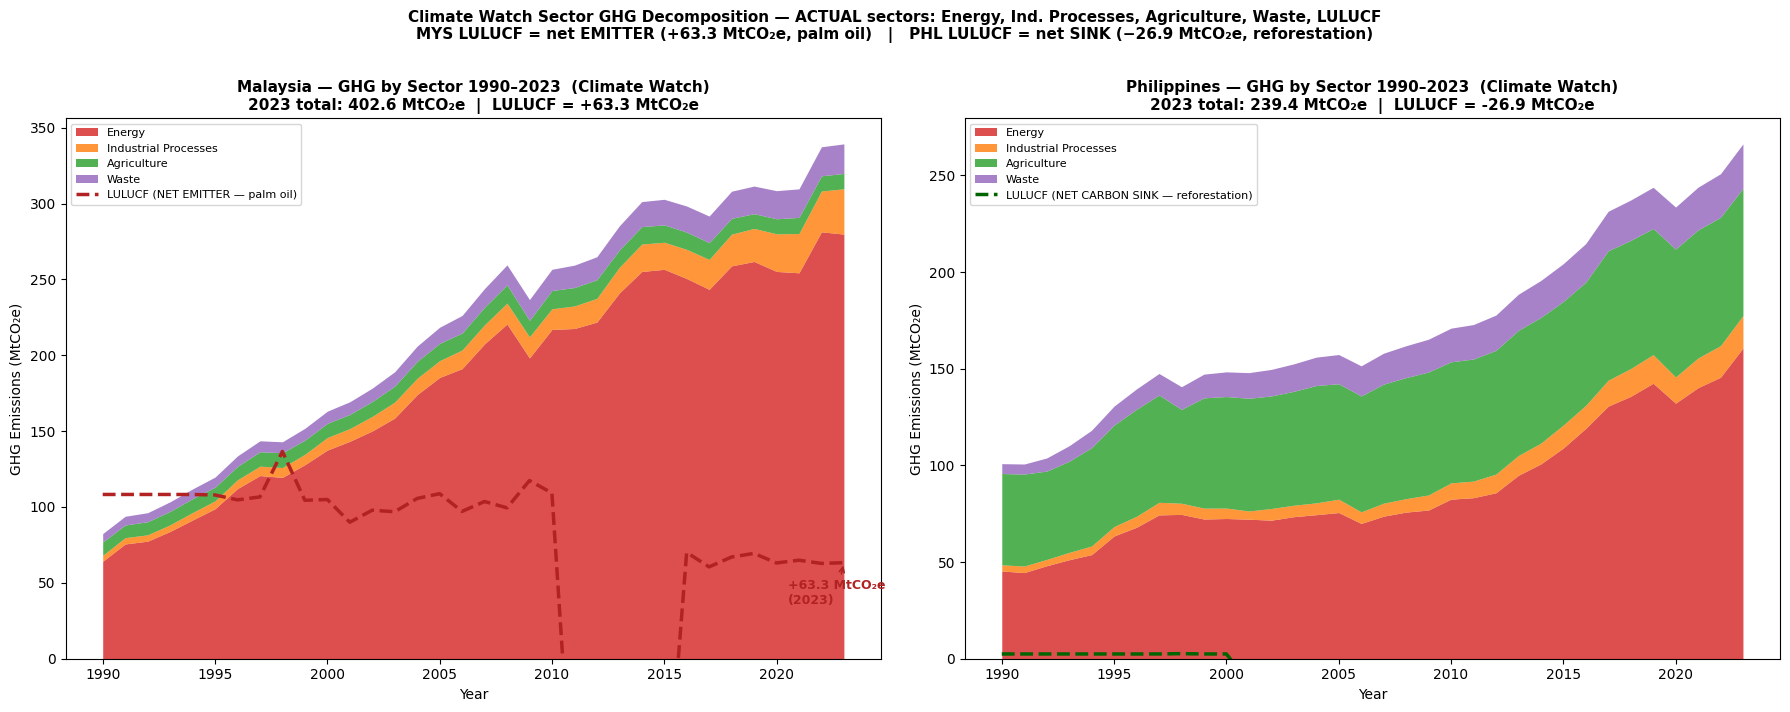

✅ Saved r1_cw_sector_decomposition.png


In [13]:
# ── Cell 3: Chart 1 - Sector Decomposition (Climate Watch) ───────────────
# WHY: Visualizes the GHG emission profile by sector to identify transition
# risk exposure. We use stacked area charts to reveal the structural differences
# between MYS (palm oil/emitter) and PHL (reforestation/sink). This highlights
# the asymmetry in regulatory risk between the two portfolios.

sector_colors = {
    'Energy':                                    '#d62728',
    'Industrial Processes':                      '#ff7f0e',
    'Agriculture':                               '#2ca02c',
    'Waste':                                     '#9467bd',
    'Land Use, Land-Use Change and Forestry':    '#8c564b',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, country, df_cw in [
    (axes[0], 'Malaysia',    df_cw_mys),
    (axes[1], 'Philippines', df_cw_phl),
]:
    pivot = df_cw.pivot_table(
        index='year', columns='Sector', values='ghg_mtco2e'
    ).fillna(0)

    non_lulucf = [c for c in REAL_SECTORS if c != LULUCF and c in pivot.columns]

    # Stacked area for all sectors except LULUCF
    pivot[non_lulucf].plot.area(
        ax=ax,
        color=[sector_colors[c] for c in non_lulucf],
        alpha=0.82,
        linewidth=0,
    )

    # LULUCF as dashed line (can be negative for PHL)
    if LULUCF in pivot.columns:
        lulucf_vals = pivot[LULUCF]
        lulucf_2023 = lulucf_vals.iloc[-1]
        sign_label = 'NET EMITTER — palm oil' if lulucf_2023 > 0 else 'NET CARBON SINK — reforestation'
        line_color = '#b22222' if lulucf_2023 > 0 else '#006400'
        ax.plot(pivot.index, lulucf_vals, color=line_color,
                linewidth=2.5, linestyle='--',
                label=f'LULUCF ({sign_label})')
        ax.axhline(0, color='black', linewidth=0.6, alpha=0.35)
        ax.annotate(
            f'{"+" if lulucf_2023>0 else ""}{lulucf_2023:.1f} MtCO₂e\n(2023)',
            xy=(pivot.index[-1], lulucf_2023),
            xytext=(-40, 20 if lulucf_2023 < 0 else -30),
            textcoords='offset points',
            fontsize=9, fontweight='bold', color=line_color,
            arrowprops=dict(arrowstyle='->', color=line_color, lw=1.2),
        )

    total_2023 = pivot.loc[2023].sum() if 2023 in pivot.index else np.nan
    ax.set_title(
        f'{country} — GHG by Sector 1990–2023  (Climate Watch)\n'
        f'2023 total: {total_2023:.1f} MtCO₂e  |  '
        f'LULUCF = {"+" if lulucf_2023>0 else ""}{lulucf_2023:.1f} MtCO₂e',
        fontweight='bold', fontsize=11,
    )
    ax.set_ylabel('GHG Emissions (MtCO₂e)')
    ax.set_xlabel('Year')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, fontsize=8, loc='upper left')

fig.suptitle(
    'Climate Watch Sector GHG Decomposition — ACTUAL sectors: Energy, Ind. Processes, Agriculture, Waste, LULUCF\n'
    'MYS LULUCF = net EMITTER (+63.3 MtCO₂e, palm oil)   |   PHL LULUCF = net SINK (−26.9 MtCO₂e, reforestation)',
    fontsize=11, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig(OUT / "r1_cw_sector_decomposition.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved r1_cw_sector_decomposition.png")


## Chart 2 — WDI GHG Growth × Urbanisation (Dual-Axis, Both Countries, 1990–2023)

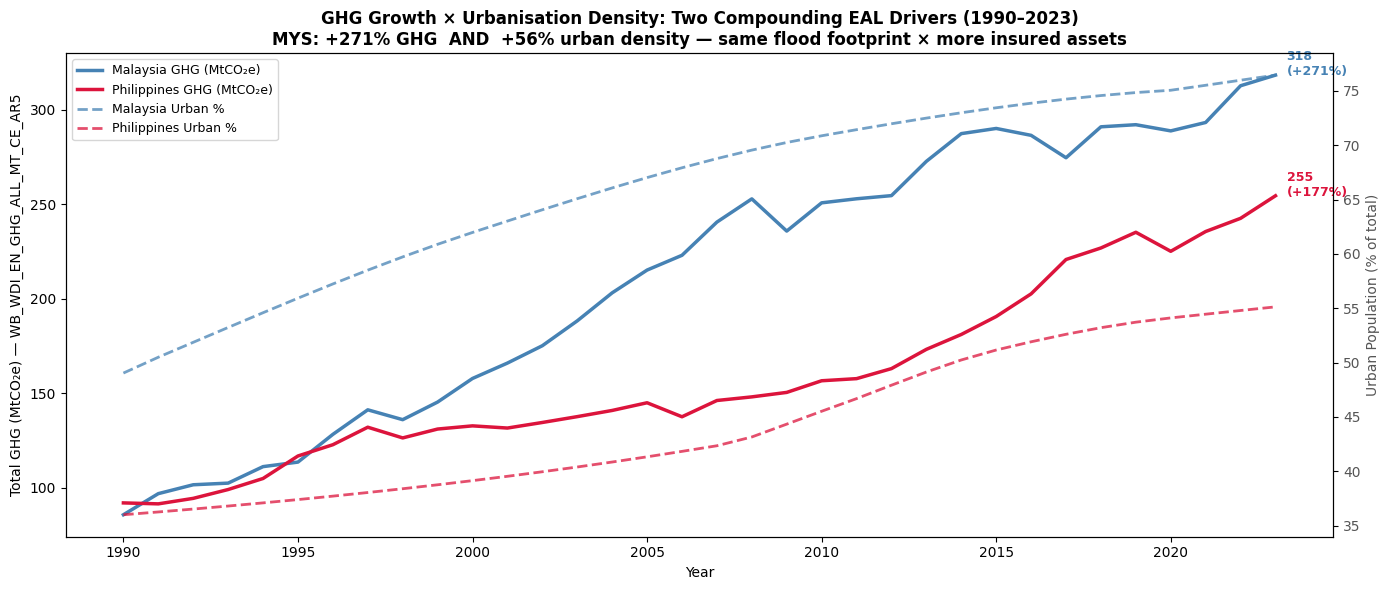

✅ Saved r1_ghg_urban_dual_axis.png


In [14]:
# ── Cell 4: Chart 2 - GHG vs Urbanization (Dual-Axis) ────────────────────
# WHY: Overlays total GHG emissions against urban population growth. This
# dual-axis approach demonstrates the compounding nature of climate risk:
# rising emissions drive physical hazards, while rapid urbanization
# concentrates more insured assets in those exposed hazard zones.

GHG_COL   = 'WB_WDI_EN_GHG_ALL_MT_CE_AR5'   # verified actual column name
URBAN_COL = 'SP.URB.TOTL.IN.ZS'

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

country_styles = {
    'MYS': {'color': 'steelblue',  'label': 'Malaysia'},
    'PHL': {'color': 'crimson',    'label': 'Philippines'},
}

for code, style in country_styles.items():
    df_c = df_wdi[df_wdi['country_code'] == code].sort_values('year')
    ax1.plot(df_c['year'], df_c[GHG_COL], color=style['color'],
             linewidth=2.5, label=f"{style['label']} GHG (MtCO₂e)")
    ax2.plot(df_c['year'], df_c[URBAN_COL], color=style['color'],
             linewidth=2.0, linestyle='--', alpha=0.75,
             label=f"{style['label']} Urban %")

    # Annotate start/end values
    first = df_c.dropna(subset=[GHG_COL]).iloc[0]
    last  = df_c.dropna(subset=[GHG_COL]).iloc[-1]
    pct_chg = (last[GHG_COL] / first[GHG_COL] - 1) * 100
    ax1.annotate(
        f'{last[GHG_COL]:.0f}\n(+{pct_chg:.0f}%)',
        xy=(last['year'], last[GHG_COL]),
        xytext=(8, 0), textcoords='offset points',
        fontsize=9, fontweight='bold', color=style['color'],
    )

ax1.set_ylabel('Total GHG (MtCO₂e) — WB_WDI_EN_GHG_ALL_MT_CE_AR5', fontsize=10)
ax2.set_ylabel('Urban Population (% of total)', fontsize=10, color='#555555')
ax1.set_xlabel('Year')
ax1.set_title(
    'GHG Growth × Urbanisation Density: Two Compounding EAL Drivers (1990–2023)\n'
    'MYS: +271% GHG  AND  +56% urban density — same flood footprint × more insured assets',
    fontweight='bold',
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax2.tick_params(axis='y', labelcolor='#555555')
plt.tight_layout()
plt.savefig(OUT / "r1_ghg_urban_dual_axis.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved r1_ghg_urban_dual_axis.png")


### Linking Hazard to Financial Reality (Mechanistic Pathway)
Having established the differing baseline emission profiles and urban density pathways of Malaysia and the Philippines, we now profile actual historical realization of hazards via EM-DAT. Remember our causal linkage: the rising GHG profiles identified above scale extreme precipitation capacity (+7% per °C), which translates into these specific peril classes (Floods for MYS, Storms for PHL). We will model this explicitly using extreme value theory (GEV) in Notebook 4.

## Chart 3 — EM-DAT Hazard Profile: Malaysia vs Philippines (1905–2025)

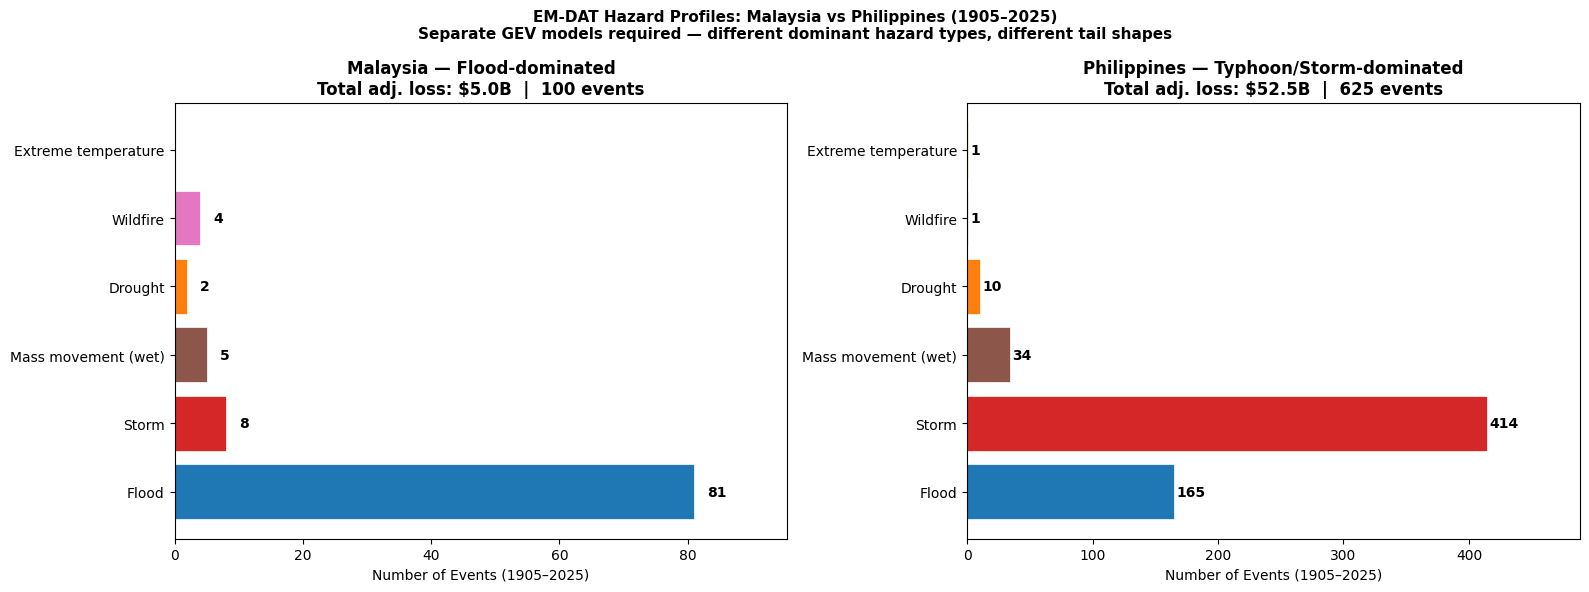

✅ Saved r1_emdat_hazard_profile.png

Malaysia  — 100 events | $5.0B adj. total loss
  Dominant: Flood (81 events) → fit GEV to flood losses

Philippines — 625 events | $52.5B adj. total loss
  Dominant: Storm (414 events) → fit GEV to typhoon losses

⚠️  Combined MYS+PHL GEV model is statistically invalid — separate models required


In [15]:
# ── Cell 5: Chart 3 - EM-DAT Hazard Profile ───────────────────────────────
# WHY: Plots historical climate-related disaster frequency (1905-2025).
# This validates the physical risk thesis by proving that the dominant peril
# in MYS is flooding, while PHL is dominated by storms/typhoons.
# Understanding this peril divergence is critical for reinsurance pricing.

DISASTER_COLORS = {
    'Flood':                  '#1f77b4',
    'Storm':                  '#d62728',
    'Mass movement (wet)':    '#8c564b',
    'Drought':                '#ff7f0e',
    'Wildfire':               '#e377c2',
    'Extreme temperature':    '#bcbd22',
}
DISASTER_ORDER = list(DISASTER_COLORS.keys())

# Event counts per country
mys_counts = (
    df_emdat[df_emdat['country'] == 'Malaysia']
    .groupby('disaster_type').size()
    .reindex(DISASTER_ORDER, fill_value=0)
)
phl_counts = (
    df_emdat[df_emdat['country'] == 'Philippines']
    .groupby('disaster_type').size()
    .reindex(DISASTER_ORDER, fill_value=0)
)

# Inflation-adjusted total loss per country
df_emdat['total_damage_adjusted_usd'] = pd.to_numeric(
    df_emdat['total_damage_adjusted_usd'], errors='coerce'
)
mys_loss_b = df_emdat[df_emdat['country']=='Malaysia']['total_damage_adjusted_usd'].sum() / 1e9
phl_loss_b = df_emdat[df_emdat['country']=='Philippines']['total_damage_adjusted_usd'].sum() / 1e9

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, country, counts, loss_b, dominant in [
    (axes[0], 'Malaysia',    mys_counts, mys_loss_b, 'Flood-dominated'),
    (axes[1], 'Philippines', phl_counts, phl_loss_b, 'Typhoon/Storm-dominated'),
]:
    colors = [DISASTER_COLORS[d] for d in DISASTER_ORDER]
    bars = ax.barh(DISASTER_ORDER, counts.values, color=colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, counts.values):
        if val > 0:
            ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                    str(int(val)), va='center', fontsize=10, fontweight='bold')
    ax.set_xlabel('Number of Events (1905–2025)')
    ax.set_title(
        f'{country} — {dominant}\n'
        f'Total adj. loss: ${loss_b:.1f}B  |  {int(counts.sum())} events',
        fontweight='bold',
    )
    ax.set_xlim(0, counts.max() * 1.18)

fig.suptitle(
    'EM-DAT Hazard Profiles: Malaysia vs Philippines (1905–2025)\n'
    'Separate GEV models required — different dominant hazard types, different tail shapes',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.savefig(OUT / "r1_emdat_hazard_profile.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved r1_emdat_hazard_profile.png")
print()
print(f"Malaysia  — {int(mys_counts.sum())} events | ${mys_loss_b:.1f}B adj. total loss")
print(f"  Dominant: Flood ({int(mys_counts['Flood'])} events) → fit GEV to flood losses")
print()
print(f"Philippines — {int(phl_counts.sum())} events | ${phl_loss_b:.1f}B adj. total loss")
print(f"  Dominant: Storm ({int(phl_counts['Storm'])} events) → fit GEV to typhoon losses")
print()
print("⚠️  Combined MYS+PHL GEV model is statistically invalid — separate models required")
